# Weryfikacja ekstrakcji Vision — pojedyncza strona (p.54)

Eksperyment: pierwszy pass Vision (`backend/app/document/vision_extractor.py`) na p.54 wyprodukował halucynację — fragment "POLSIF **prezentuje klimatyczniejszego przedsiębiorcy włodarych**..." zamiast "POLSIF zrzesza kilkudziesięciu przedstawicieli wiodących...".

Hipoteza: drugi pass Vision, który dostaje obraz strony **oraz** wcześniej wyekstrahowany tekst i jest proszony o korektę, wykryje i naprawi ten błąd.

Pipeline notebooka: cache → oryginalny tekst → obraz strony → drugi pass Vision (prompt weryfikacyjny) → diff + lista korekt + test boolowski na POLSIF.

## 1. Setup

In [45]:
%load_ext autoreload
%autoreload 2

import base64
import difflib
import json
import os
import sys
from pathlib import Path

import anthropic
import pandas as pd
import pymupdf
from dotenv import load_dotenv
from IPython.display import HTML, Image, Markdown, display

ROOT = Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from backend.app.config import VISION_CACHE_DIR, VISION_MODEL
from backend.app.document.image_renderer import apply_cropboxes, page_to_base64
from backend.app.document.models import ExtractedChapter
from backend.app.document.vision_response import clean_response

load_dotenv(ROOT / ".env")
assert os.getenv("ANTHROPIC_API_KEY"), "Brak ANTHROPIC_API_KEY w env/.env"

PDF_PATH = ROOT / "data" / "raw" / "raport_2024_pl.pdf"
CHAPTER_ID = "V"
PAGE_NUM = 54
print(f"model: {VISION_MODEL}")
print(f"pdf:   {PDF_PATH}")
print(f"cache: {VISION_CACHE_DIR / (CHAPTER_ID + '.json')}")
VISION_MODEL = "claude-sonnet-4-6"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
model: claude-haiku-4-5-20251001
pdf:   c:\mirror\zadanie\docquery\data\raw\raport_2024_pl.pdf
cache: C:\mirror\zadanie\docquery\data\extraction\V.json


## 2. Wczytaj zcache'owaną ekstrakcję strony

In [46]:
chapter = ExtractedChapter.load_json(VISION_CACHE_DIR / f"{CHAPTER_ID}.json")
page = next(p for p in chapter.pages if p.page_num == PAGE_NUM)


def page_to_text(p) -> str:
    return "\n\n".join(f"[{b.element_type}] {b.text}" for b in p.blocks)


original_text = page_to_text(page)
print(f"Strona {PAGE_NUM}: {len(page.blocks)} bloków, {len(original_text)} znaków")
display(Markdown(f"```\n{original_text}\n```"))

Strona 54: 12 bloków, 4690 znaków


```
[section-header] 1. Zrównoważony rozwój

[subsection-header] GRI 3-3 temat: Zmiana klimatu

[text] Chcemy wesprzeć rozwój społeczny i gospodarczy kraju, tak aby wspokajać potrzeby współczesnego społeczeństwa i tworzyć lepsze warunki do życia dla następnych pokoleń. Przystąpiliśmy do operacjonalizacji nowej strategii, jesteśmy w trakcie weryfikacji przyjętych dotychczas kierunków działań w odpowiedzi na zidentyfikowane wyzwania.

[text] Jako bank zobowiązaliśmy się do opracowania ścieżek dekarbonizacji dla poszczególnych sektorów. W 2024 roku opracowaliśmy takie ścieżki dla dwóch pierwszych sektorów istotnych zarówno z perspektywy emisji, jak i udziału w portfelu naszych finansów. W oparciu o doświadczenia z tego ćwiczenia będziemy w kolejnych latach pracować nad pozostałymi branżami, aby urzeczywistnić długoterminowe cele dekarbonizacyjne.

[text] Przystąpiliśmy także do Partnership for Carbon Accounting Financials (PCAF), międzynarodowego partnerstwa instytucji finansowych, które współpracują ze sobą w celu opracowania i wdrażania globalnych standardów podejścia do kalkulacji i raportowania emisji gazów cieplarnianych generowanych z pożyczkami i inwestycjami. Do 2025 r. jesteśmy też członkiem stowarzyszenia POLSIF, którego misją jest rozwijanie oraz promowanie polskiego i europejskiego rynku zrównoważonych inwestycji i finansów. POLSIF prezentuje klimatyczniejszego przedsiębiorcy włodarych towarzystw funduszu inwestycyjnych, banków, funduszy private equity, organizacji i izb branżowych oraz świata nauki.

[text] Wciąż doskonalimy ankietę ESG - główny kanał pozyskiwania danych o partnerach i finansowanych. W 2023 nie uprawnieniu tzw EG (Filar III, ESG), wypracowaliśmy metodologie szacowania wartości efektywności energetycznej nieruchomości, po raz pierwszy wdrażaliśmy Scenic Asset Ratio (GAR) oraz emisje gazów cieplarnianych (GHG) w portfelu działalności własnej. W 2024 roku wypracowaliśmy również metodologię licencji wskaźnika Banking-book Taxonomy Alignment Ratio (BTAR).

[text] Konsekwentnie zwiększamy świadomość interesariuszy w zakresie ESG. Eksperci BGK biorą udział w konferencjach, webinarach i studiach popołudniowych. Bank opracował szkolenie z podstaw ESG dla małych i średnich przedsiębiorstw oraz przeprowadził cykl edukacyjny szkolenie ESG w miastach dla Unii Metropolii Polskich. Potrzeby kluczowych interesariuszy identyfikujemy regularnie, organizując panele dialogu zgodnie ze standardem AA1000SES.

[picture] Portret mężczyzny w średnim wieku, ubranego w garnitur i niebieski krawat, na białym tle. Zdjęcie jest umieszczone w prawym górnym rogu strony obok tekstu.

[text] W BGK łączymy ambicje ESG z realnym działaniem - rozwijamy metodologie licencja emisji, zarządzamy ryzykiem ESG u wybieranych, zasady ładu korporacyjnego mają i dyskusji o zrównoważonej przyszłości. Działały odpowiedzialnie. bo wiemy, ze zrównoważony rozwój to fundament bezpieczeństwa i odporności gospodarki.

[text] Mateusz Szczurek. Człowiek Zarządu BGK

[text] Rozwijamy także świadomość ESG wewnątrz organizacji. W 2024 r. kontynuowaliśmy program ombodsmanów Zrównoważony Rozwój, nagrodzony w konkursie Dream Employer, który systematycznie podnosi świadomość kwestii społecznych i środowiskowych wśród pracowników. Do drugiej edycji programu dotyczyła ponad 10 osób z razem komisji organizacyjnych banku. Tematem przewodnim spotkań jest realny, namacanty wpływ BGK na realizację celów zrównoważonego rozwoju, ze szczególnym uwzględnieniem działań na rzecz ochrony środowiska, odpowiedzialności społecznej i efektywności operacyjnej. Program stał się platformą wymiany wiedzy i doświadczeń, umożliwiając uczestnikom lepsze zrozumienie walizacji roli pracowników w budowaniu zrównoważonej przyszłości.

[text] Rozbudowujemy też podejście oraz narzędzia do zarządzania ryzykami ESG. Monitorujemy limit strategiczny w zakresie ryzyka ESG (więcej w rozdziale VI.6. Ryzyko ESG), a 2024 r. przeprowadziliśmy pierwszą próbę testów warunków skrajnych ryzyk związanych z klimatem. w oparciu o metodykę europejskiego Banku Centralnego (na podstawie scenariuszy NGFS). Zgodność BGK ze standardami ESG zweryfikowała agencja ratingowa Sustainable Fitch podniosząc naszą ocenę do 64 oraz przyznając ponownie w 2024 r. rating ESG na poziomie 2+ w skali 1-5, góre. Te wartość najwyższa. w uzupełnieniu skąpej ceny prześlizła, że z perspektywy społecznej bank przyczynił się nie.dn. do realizacji 17 celów zrównoważego rozpioru ONZ (partnerstwa na rzecz celów) poprzez uczestnictwo i wspólpracy z międzynarodowymi instytucjami finansowymi. Sustainable Fitch pozytywnie oceniła niezłatych staranność banku, a także ochronę i promownie praw człowieka oraz polityki społecznej.
```

## 3. Wyrenderuj obraz strony (ground truth wizualny)

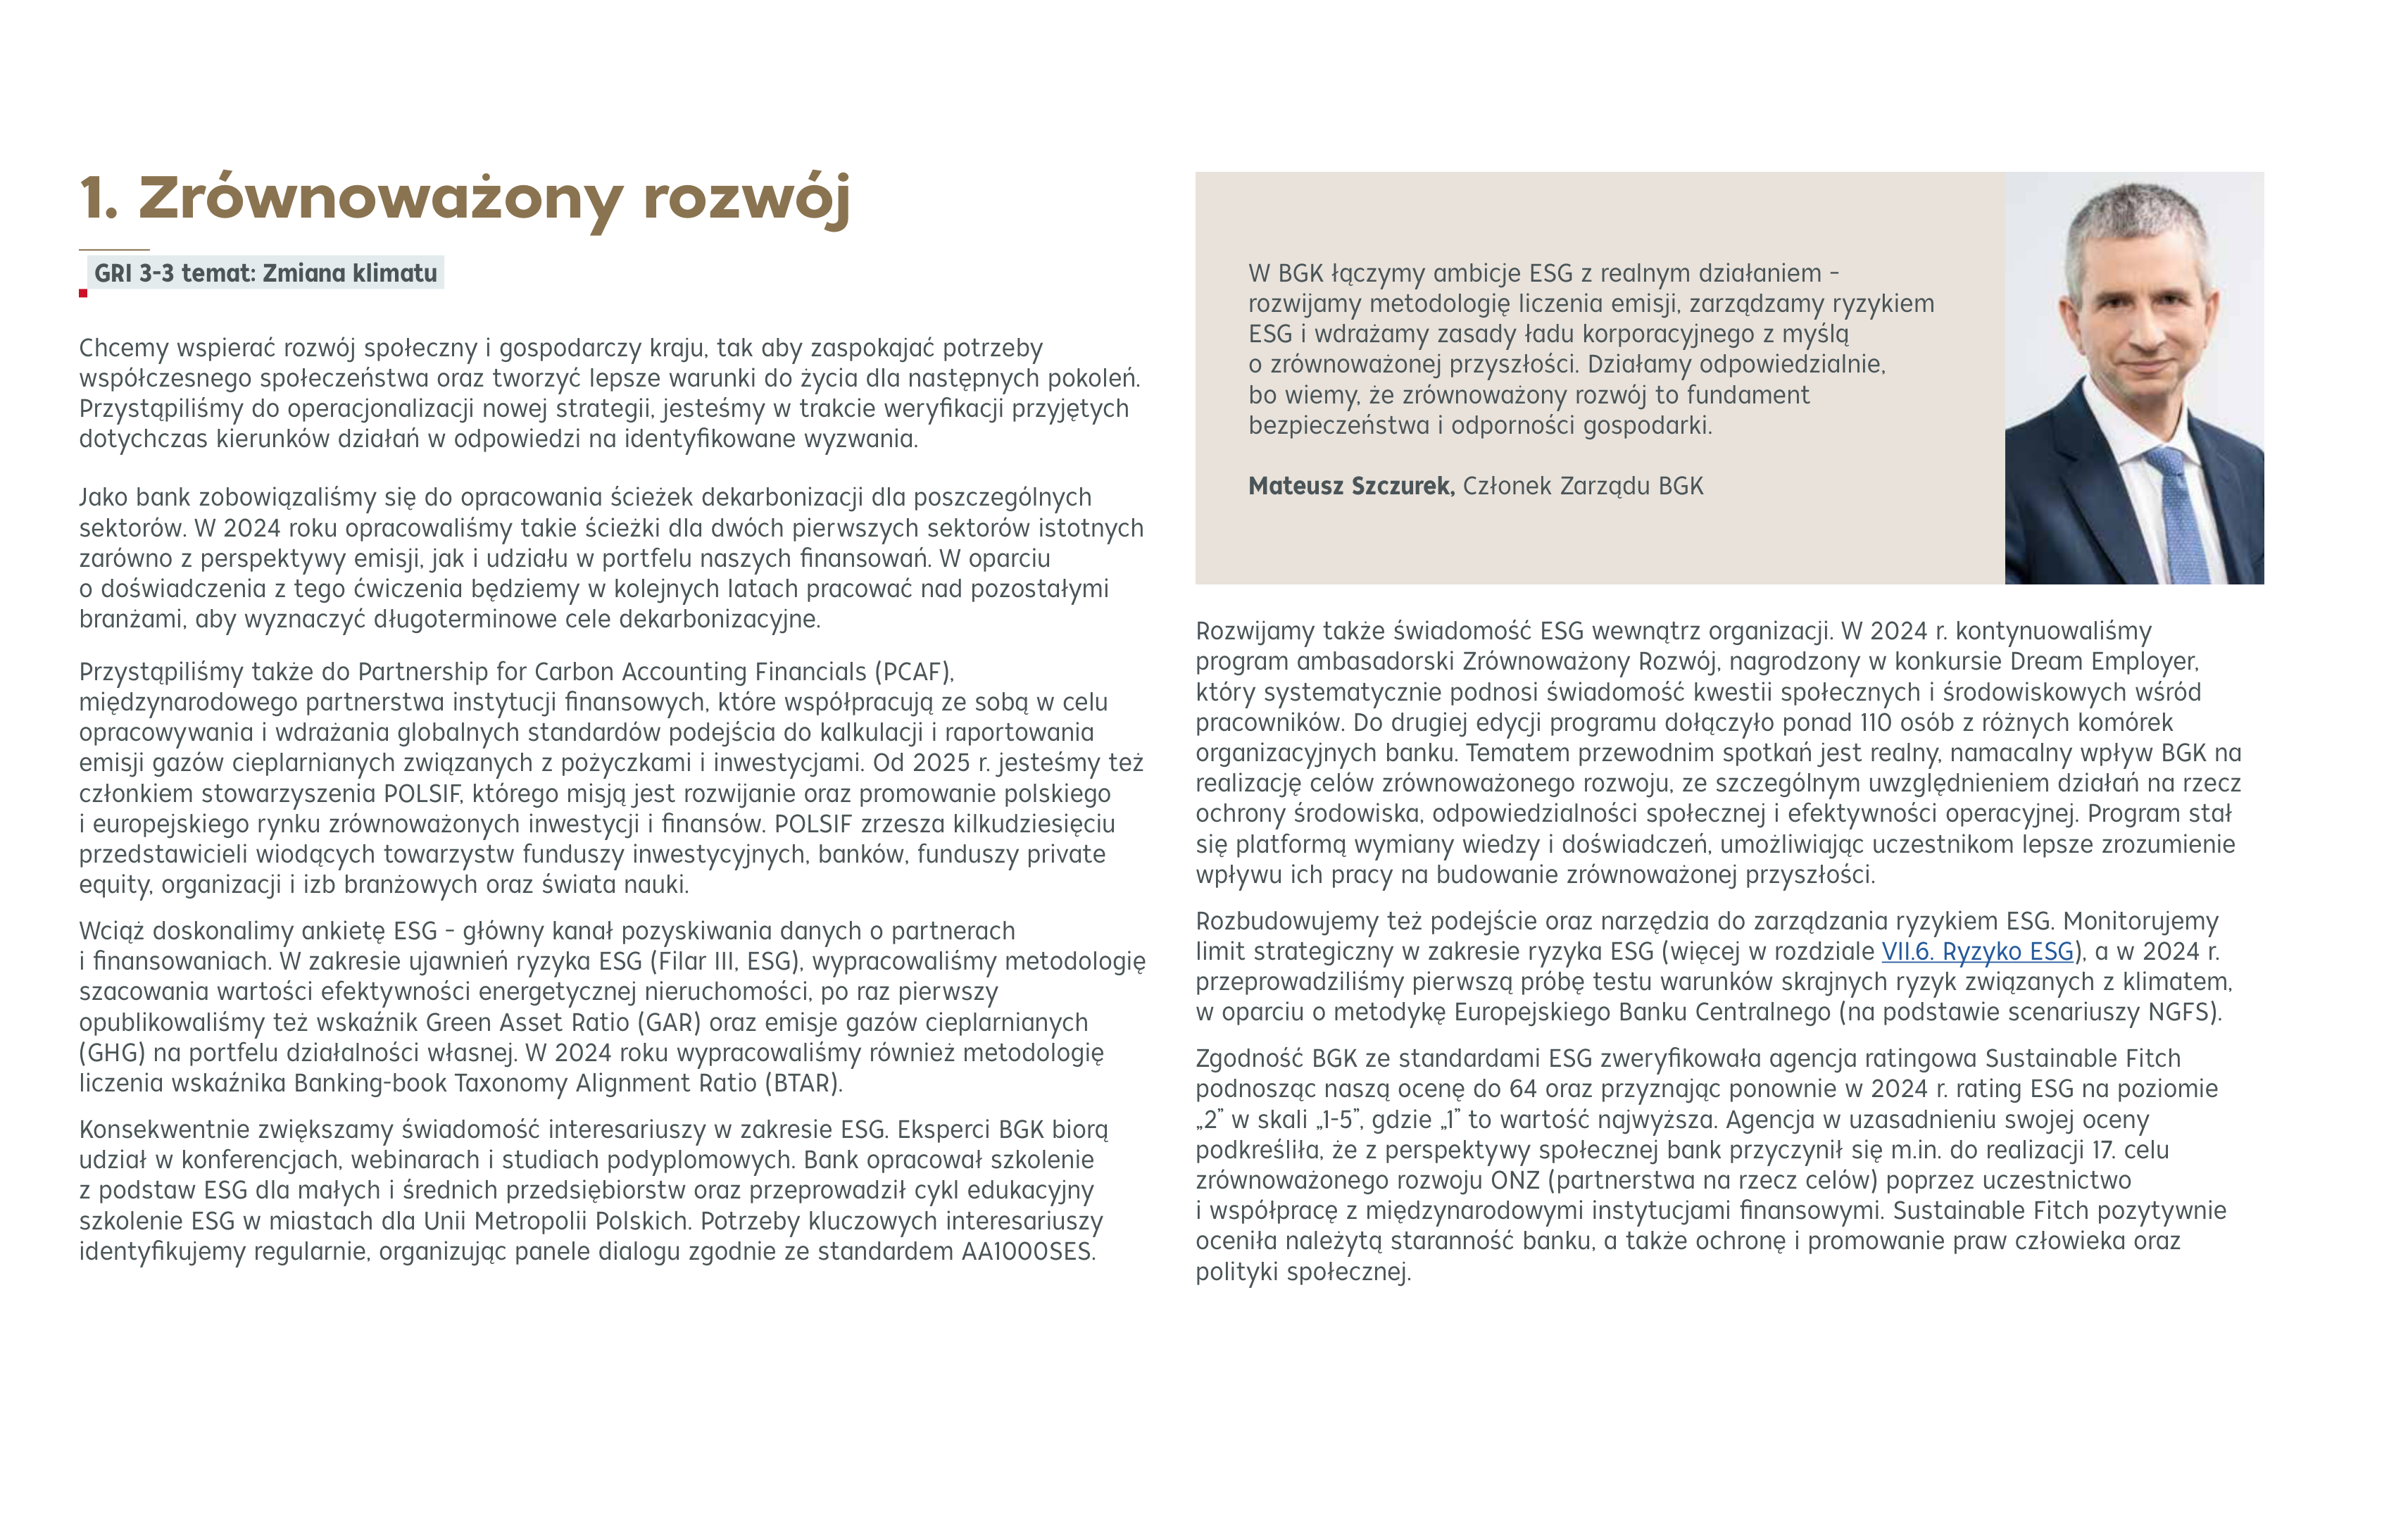

In [47]:
doc = pymupdf.open(PDF_PATH)
apply_cropboxes(doc, [page])
image_b64, media_type = page_to_base64(doc, page)
display(Image(data=base64.b64decode(image_b64), format="jpeg" if "jpeg" in media_type else "png"))

## 4. Prompt weryfikacyjny

Instrukcja skupiona wyłącznie na **punktowych korektach** — Vision ma zwrócić listę konkretnych rozbieżności oraz pełny skorygowany tekst. Bez swobodnego przepisywania fragmentów, które są już poprawne.

In [48]:
VERIFY_SYSTEM_PROMPT = """You are a strict proofreader.

You receive two inputs:
1. An image of a single PDF page.
2. A text previously extracted from that page (may contain OCR-like errors).

Your task: compare the extracted text against the image and produce ONLY factual corrections — cases where the extracted text differs from what is literally printed on the image.

Rules:
- Do NOT rewrite passages that already match the image. Keep them verbatim.
- Do NOT correct stylistics, grammar, or formatting — only mismatches with the image.
- Preserve the element-type prefixes in square brackets (e.g. \"[text]\", \"[section-header]\") exactly as in the input.
- Preserve Polish diacritics (ą, ć, ę, ł, ń, ó, ś, ź, ż). If the extracted text uses \"?\" or mojibake where a diacritic should be, restore the correct letter.
- If the extracted text is fully correct, return an empty corrections array.
- CRITICAL: the field \"original\" MUST be copied verbatim from the previously extracted text — an exact substring of the input, including any OCR errors. Do NOT paraphrase, shorten, fix diacritics in it, or clean it up. Our pipeline applies corrections by literal string replacement (original → corrected), so any paraphrase in \"original\" makes the correction unusable.
- If the image is hard to read and you are not 100% sure of the exact wording, still output your best-effort reading in \"corrected\" and note the uncertainty in \"reason\" (e.g. \"niepewny odczyt — obraz nieczytelny\"). Never leave a mismatch unreported once you have identified it.

Output format — a single JSON object, no markdown fences, no commentary:

{
  \"corrections\": [
    {\"original\": \"<verbatim substring of the extracted text>\", \"corrected\": \"<what the image actually says>\", \"reason\": \"<short Polish explanation>\"}
  ]
}
"""
print(VERIFY_SYSTEM_PROMPT)

You are a strict proofreader.

You receive two inputs:
1. An image of a single PDF page.
2. A text previously extracted from that page (may contain OCR-like errors).

Your task: compare the extracted text against the image and produce ONLY factual corrections — cases where the extracted text differs from what is literally printed on the image.

Rules:
- Do NOT rewrite passages that already match the image. Keep them verbatim.
- Do NOT correct stylistics, grammar, or formatting — only mismatches with the image.
- Preserve the element-type prefixes in square brackets (e.g. "[text]", "[section-header]") exactly as in the input.
- Preserve Polish diacritics (ą, ć, ę, ł, ń, ó, ś, ź, ż). If the extracted text uses "?" or mojibake where a diacritic should be, restore the correct letter.
- If the extracted text is fully correct, return an empty corrections array.
- CRITICAL: the field "original" MUST be copied verbatim from the previously extracted text — an exact substring of the input, inclu

## 5. Funkcja weryfikująca (reuse w notebooku batch)

In [49]:
def verify_page(
    client: anthropic.Anthropic,
    doc: pymupdf.Document,
    page,
    original_text: str,
    model: str = VISION_MODEL,
) -> dict:
    """Drugi pass Vision: obraz + tekst → JSON z korektami."""
    img_b64, media_type = page_to_base64(doc, page)
    user_content = [
        {
            "type": "image",
            "source": {"type": "base64", "media_type": media_type, "data": img_b64},
        },
        {
            "type": "text",
            "text": f"Previously extracted text:\n\n{original_text}",
        },
    ]
    resp = client.messages.create(
        model=model,
        max_tokens=4096,
        system=VERIFY_SYSTEM_PROMPT,
        messages=[{"role": "user", "content": user_content}],
    )
    parsed = clean_response(resp.content[0].text)
    parsed["_usage"] = {
        "input_tokens": resp.usage.input_tokens,
        "output_tokens": resp.usage.output_tokens,
    }
    return parsed


client = anthropic.Anthropic()
result = verify_page(client, doc, page, original_text)
print(f"n_corrections: {len(result.get('corrections', []))}")
print(f"usage: {result['_usage']}")

[json_repair] Broken JSON (Expecting ',' delimiter: line 55 column 193 (char 7600)) — próbuję naprawić...
[json_repair] Naprawa udana. Fragment: '{\n  "corrections": [\n    {\n      "original": "Chcemy wesprzeć rozwój społeczny i gospodarczy kraju, tak aby wspokajać potrzeby współczesnego społeczeństwa i tworzyć lepsze warunki do życia dla następn'


n_corrections: 11
usage: {'input_tokens': 3675, 'output_tokens': 3144}


In [50]:
result

{'corrections': [{'original': 'Chcemy wesprzeć rozwój społeczny i gospodarczy kraju, tak aby wspokajać potrzeby współczesnego społeczeństwa i tworzyć lepsze warunki do życia dla następnych pokoleń.',
   'corrected': 'Chcemy wspierać rozwój społeczny i gospodarczy kraju, tak aby zaspokajać potrzeby współczesnego społeczeństwa oraz tworzyć lepsze warunki do życia dla następnych pokoleń.',
   'reason': "Błędne słowa: 'wesprzeć' zamiast 'wspierać', 'wspokajać' zamiast 'zaspokajać', 'i tworzyć' zamiast 'oraz tworzyć'"},
  {'original': 'aby urzeczywistnić długoterminowe cele dekarbonizacyjne.',
   'corrected': 'aby wyznaczyć długoterminowe cele dekarbonizacyjne.',
   'reason': "Błędny zwrot: 'urzeczywistnić' zamiast 'wyznaczyć'"},
  {'original': 'emisji gazów cieplarnianych generowanych z pożyczkami i inwestycjami. Do 2025 r. jesteśmy też członkiem stowarzyszenia POLSIF, którego misją jest rozwijanie oraz promowanie polskiego i europejskiego rynku zrównoważonych inwestycji i finansów. POLSIF

## 6. Tabela korekt

In [51]:
corrections = result.get("corrections", [])
if corrections:
    df = pd.DataFrame(corrections)
    display(df)
else:
    print("Brak korekt — Vision uznał tekst za w pełni zgodny z obrazem.")

,original,corrected,reason
0,Chcemy wesprzeć rozwój społeczny i gospodarczy...,Chcemy wspierać rozwój społeczny i gospodarczy...,"Błędne słowa: 'wesprzeć' zamiast 'wspierać', '..."
1,aby urzeczywistnić długoterminowe cele dekarbo...,aby wyznaczyć długoterminowe cele dekarbonizac...,Błędny zwrot: 'urzeczywistnić' zamiast 'wyznac...
2,emisji gazów cieplarnianych generowanych z poż...,emisji gazów cieplarnianych związanych z pożyc...,Błędne słowa: 'generowanych' zamiast 'związany...
3,"W 2023 nie uprawnieniu tzw EG (Filar III, ESG)...","W zakresie ujawnień ryzyka ESG (Filar III, ESG...",Cały akapit był mocno zniekształcony: 'W 2023 ...
4,"udział w konferencjach, webinarach i studiach ...","udział w konferencjach, webinarach i studiach ...",Błędne słowo: 'popołudniowych' zamiast 'podypl...
5,W BGK łączymy ambicje ESG z realnym działaniem...,W BGK łączymy ambicje ESG z realnym działaniem...,Cały akapit był zniekształcony: 'metodologie l...
6,Mateusz Szczurek. Człowiek Zarządu BGK,"Mateusz Szczurek, Członek Zarządu BGK",Błąd w interpunkcji (kropka zamiast przecinka)...
7,"program ombodsmanów Zrównoważony Rozwój, nagro...","program ambasadorski Zrównoważony Rozwój, nagr...",Błędne słowa: 'ombodsmanów' zamiast 'ambasador...
8,Rozbudowujemy też podejście oraz narzędzia do ...,Rozbudowujemy też podejście oraz narzędzia do ...,Błędna forma: 'ryzykami' zamiast 'ryzykiem'
9,a 2024 r. przeprowadziliśmy pierwszą próbę tes...,a w 2024 r. przeprowadziliśmy pierwszą próbę t...,Brak 'w' przed '2024 r.' oraz 'testów' zamiast...


In [52]:
corrections

[{'original': 'Chcemy wesprzeć rozwój społeczny i gospodarczy kraju, tak aby wspokajać potrzeby współczesnego społeczeństwa i tworzyć lepsze warunki do życia dla następnych pokoleń.',
  'corrected': 'Chcemy wspierać rozwój społeczny i gospodarczy kraju, tak aby zaspokajać potrzeby współczesnego społeczeństwa oraz tworzyć lepsze warunki do życia dla następnych pokoleń.',
  'reason': "Błędne słowa: 'wesprzeć' zamiast 'wspierać', 'wspokajać' zamiast 'zaspokajać', 'i tworzyć' zamiast 'oraz tworzyć'"},
 {'original': 'aby urzeczywistnić długoterminowe cele dekarbonizacyjne.',
  'corrected': 'aby wyznaczyć długoterminowe cele dekarbonizacyjne.',
  'reason': "Błędny zwrot: 'urzeczywistnić' zamiast 'wyznaczyć'"},
 {'original': 'emisji gazów cieplarnianych generowanych z pożyczkami i inwestycjami. Do 2025 r. jesteśmy też członkiem stowarzyszenia POLSIF, którego misją jest rozwijanie oraz promowanie polskiego i europejskiego rynku zrównoważonych inwestycji i finansów. POLSIF prezentuje klimatyczn

## 6a. Składanie skorygowanego tekstu lokalnie

Model zwraca tylko listę korekt (`{original, corrected, reason}`). Finalny tekst budujemy sami — dla każdej korekty sprawdzamy czy `original` występuje dosłownie w `original_text`. Jeśli tak → aplikujemy `str.replace(..., 1)`. Jeśli nie → trafia do `unmatched` i NIE jest aplikowana (chronimy się przed parafrazami modelu).

In [53]:
def apply_corrections(original: str, corrections: list[dict]) -> dict:
    """Aplikuje korekty lokalnie na oryginalnym tekście.

    Dla każdej korekty liczy ile razy `original` występuje w tekście:
    - 0 → trafia do `unmatched` (model sparafrazował — nie aplikujemy, żeby nie halucynować).
    - >=1 → `text.replace(original, corrected, 1)` (pierwsze wystąpienie),
              dopisuje info o liczbie wystąpień (>1 = ambiguous).
    """
    text = original
    applied, unmatched = [], []
    for c in corrections:
        o = c.get("original", "")
        if not o:
            unmatched.append(c)
            continue
        cnt = text.count(o)
        if cnt == 0:
            unmatched.append(c)
            continue
        text = text.replace(o, c.get("corrected", ""), 1)
        applied.append({**c, "occurrences": cnt})
    return {"corrected_text": text, "applied": applied, "unmatched": unmatched}


assembly = apply_corrections(original_text, corrections)
corrected_full = assembly["corrected_text"]
print(f"zgłoszonych korekt: {len(corrections)}")
print(f"applied:            {len(assembly['applied'])}")
print(f"unmatched:          {len(assembly['unmatched'])}")

zgłoszonych korekt: 11
applied:            11
unmatched:          0


### Unmatched — korekty, których `original` nie znaleziono w tekście

Jeżeli poniższa tabela nie jest pusta, model zgłosił poprawkę, ale jako `original` wpisał fragment, którego nie ma dosłownie w naszym tekście (prawdopodobnie sparafrazował). Takie korekty NIE zostały zaaplikowane — trzeba je przejrzeć ręcznie.

In [54]:
if assembly["unmatched"]:
    display(pd.DataFrame(assembly["unmatched"]))
else:
    print("Brak — każda zgłoszona korekta miała 'original' znalezione w oryginalnym tekście.")

Brak — każda zgłoszona korekta miała 'original' znalezione w oryginalnym tekście.


## 7. Unified diff (oryginał vs. skorygowany)

In [55]:
diff = list(
    difflib.unified_diff(
        original_text.splitlines(),
        corrected_full.splitlines(),
        fromfile="original",
        tofile="corrected",
        lineterm="",
    )
)


def colorize(lines):
    out = []
    for line in lines:
        esc = (
            line.replace("&", "&amp;")
            .replace("<", "&lt;")
            .replace(">", "&gt;")
        )
        if line.startswith("+") and not line.startswith("+++"):
            out.append(f"<span style='color:#2a7'>{esc}</span>")
        elif line.startswith("-") and not line.startswith("---"):
            out.append(f"<span style='color:#c33'>{esc}</span>")
        elif line.startswith("@@"):
            out.append(f"<span style='color:#88a'>{esc}</span>")
        else:
            out.append(esc)
    return "<br>".join(out)


if diff:
    display(HTML(f"<pre style='font-size:12px;line-height:1.4'>{colorize(diff)}</pre>"))
else:
    print("Brak różnic między oryginałem a tekstem po weryfikacji.")

In [56]:
corrected_full

'[section-header] 1. Zrównoważony rozwój\n\n[subsection-header] GRI 3-3 temat: Zmiana klimatu\n\n[text] Chcemy wspierać rozwój społeczny i gospodarczy kraju, tak aby zaspokajać potrzeby współczesnego społeczeństwa oraz tworzyć lepsze warunki do życia dla następnych pokoleń. Przystąpiliśmy do operacjonalizacji nowej strategii, jesteśmy w trakcie weryfikacji przyjętych dotychczas kierunków działań w odpowiedzi na zidentyfikowane wyzwania.\n\n[text] Jako bank zobowiązaliśmy się do opracowania ścieżek dekarbonizacji dla poszczególnych sektorów. W 2024 roku opracowaliśmy takie ścieżki dla dwóch pierwszych sektorów istotnych zarówno z perspektywy emisji, jak i udziału w portfelu naszych finansów. W oparciu o doświadczenia z tego ćwiczenia będziemy w kolejnych latach pracować nad pozostałymi branżami, aby wyznaczyć długoterminowe cele dekarbonizacyjne.\n\n[text] Przystąpiliśmy także do Partnership for Carbon Accounting Financials (PCAF), międzynarodowego partnerstwa instytucji finansowych, kt

## 8. Test boolowski — czy POLSIF został naprawiony

In [57]:
GOLDEN = "POLSIF zrzesza kilkudziesięciu przedstawicieli wiodących"
BROKEN = "prezentuje klimatyczniejszego przedsiębiorcy"

had_bug = BROKEN in original_text
fixed = GOLDEN in corrected_full
bug_remains = BROKEN in corrected_full

print(f"Oryginał zawierał halucynację:         {had_bug}")
print(f"Skorygowany tekst zawiera poprawną frazę: {fixed}")
print(f"Skorygowany tekst wciąż ma halucynację:  {bug_remains}")

Oryginał zawierał halucynację:         True
Skorygowany tekst zawiera poprawną frazę: True
Skorygowany tekst wciąż ma halucynację:  False


## 9. Wnioski

_Miejsce na notatki po uruchomieniu:_
- Czy second-pass naprawił POLSIF?
- Czy wykrył inne (może nieoczywiste) błędy?
- Czy nie wprowadził regresji (np. przepisał poprawny fragment)?
- Koszt (`_usage`) vs. oryginalny pierwszy pass — czy second-pass jest opłacalny?